In [1]:
#!pip install mlflow cryptography==43.0.3 --ignore-installed blinker

  Using cached mlflow-3.14.0-py3-none-any.whl.metadata (49 kB)
  Using cached cryptography-43.0.3-cp39-abi3-manylinux_2_28_x86_64.whl.metadata (5.4 kB)
  Using cached blinker-1.9.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached cffi-2.0.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (2.6 kB)
  Using cached mlflow_skinny-3.14.0-py3-none-any.whl.metadata (50 kB)
  Using cached mlflow_tracing-3.14.0-py3-none-any.whl.metadata (19 kB)
  Using cached flask_cors-6.0.5-py3-none-any.whl.metadata (5.4 kB)
  Using cached flask-3.1.3-py3-none-any.whl.metadata (3.2 kB)
  Using cached aiohttp-3.14.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (8.3 kB)
  Using cached alembic-1.18.5-py3-none-any.whl.metadata (7.2 kB)
  Using cached docker-7.1.0-py3-none-any.whl.metadata (3.8 kB)
  Using cached graphene-3.4.3-py2.py3-none-any.whl.metadata (6.9 kB)
  Using cached gunicorn-26.0.0-py3-none-any.whl.metadata (5.4 kB)
  Using cached huey

In [1]:
!pip install pyngrok
!pip install mlflow

In [62]:
# Store your GitHub PAT securely in Colab Secrets
# Click on the '🔑' icon on the left panel, add a new secret named 'GH_TOKEN' and paste your PAT there.
from google.colab import userdata
import os

# Get the PAT from Colab secrets
GH_TOKEN = userdata.get('GH_TOKEN')

# Set it as an environment variable (optional, but good practice if cloning private repos)
os.environ['GH_TOKEN'] = GH_TOKEN

print("GitHub Token retrieved. You can now use it for cloning private repositories.")

GitHub Token retrieved. You can now use it for cloning private repositories.


In [63]:
# Replace with your GitHub email and username
!git config --global user.email "isaac_adebayojr@gmail.com"
!git config --global user.name "isaacadebayo"

print("Git user configured.")

Git user configured.


In [64]:
# Replace 'your_username' and 'your_repository' with your actual GitHub details.
# For a public repository:
!git clone https://github.com/isaacadebayo/Agentic_projects.git

# For a private repository using PAT:
# This uses the GH_TOKEN environment variable
!git clone https://{GH_TOKEN}@github.com/isaacadebayo/Agentic_projects

# Change into your repository directory to perform Git operations
%cd Agentic_projects

print("Repository cloned. You are now in the repository directory.")

Cloning into 'Agentic_projects'...
remote: Enumerating objects: 165, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 165 (delta 4), reused 1 (delta 1), pack-reused 160 (from 1)
Receiving objects: 100% (165/165), 2.10 MiB | 27.55 MiB/s, done.
Resolving deltas: 100% (76/76), done.
fatal: destination path 'Agentic_projects' already exists and is not an empty directory.
/content/Agentic_projects/Agentic_projects
Repository cloned. You are now in the repository directory.


In [65]:
# Authenticate Google Cloud for DVC to access GCS
# This will open a browser window for authentication.
# Follow the instructions to get an authorization code and paste it back.
!gcloud auth application-default login

print("Google Cloud authentication complete. You can now retry the DVC push.")

Go to the following link in your browser, and complete the sign-in prompts:

    https://accounts.google.com/o/oauth2/auth?response_type=code&client_id=764086051850-6qr4p6gpi6hn506pt8ejuq83di341hur.apps.googleusercontent.com&redirect_uri=https%3A%2F%2Fsdk.cloud.google.com%2Fapplicationdefaultauthcode.html&scope=openid+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fuserinfo.email+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fcloud-platform+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fsqlservice.login&state=SS28eHhHoCI7QqZq8NxvqtYMnxK1gx&prompt=consent&token_usage=remote&access_type=offline&code_challenge=J7LLY0uA-Afg4hvzenOMKSZcrmErNDGI1e5eFngJLWk&code_challenge_method=S256

Once finished, enter the verification code provided in your browser: 4/0AdkVLPxCbVOzjR_z4iI6DGKTqWepN2a6oHS8ZU_ibc9UWML-a4IiiVXAvpN6XeH13yMGug

Credentials saved to file: [/content/.config/application_default_credentials.json]

These credentials will be used by any library that requests Application Default Credentials (ADC).
Ca

In [66]:
# Initialize DVC within the current directory (which is the cloned Git repo)
!dvc init

# Configure Google Drive as a remote storage (replace 'dvc_storage' with your desired folder name in Google Drive)
!dvc remote add -d gdrive_remote gdrive://MyDrive/dvc_storage
!dvc remote add -d gcs_remote gs://my-agentic-chatbot-data-lake

# Create a data directory within the Git repository if it doesn't exist
!mkdir -p data

# Copy the data file into the Git repository's data directory
# This ensures the .dvc file (created by dvc add) will be within the Git repo
!cp /content/drive/MyDrive/insurance.csv data/insurance.csv

# Add a data file to DVC. This will create a .dvc file at data/aapl_stock_prices.csv.dvc
!dvc add data/insurance.csv

# To commit the .dvc file to Git (requires Git setup, which is already done)
# Now git will find the .dvc file within its repository's working directory
!git add data/insurance.csv
!git commit -m "Add credit_risk_dataset.csv to DVC"

print("DVC setup complete. Your data file is now versioned with DVC and stored in Google Drive.")
print("You can push/pull changes using: !dvc push and !dvc pull")

/bin/bash: line 1: dvc: command not found
/bin/bash: line 1: dvc: command not found
/bin/bash: line 1: dvc: command not found
/bin/bash: line 1: dvc: command not found
[main 6879fab] Add credit_risk_dataset.csv to DVC
 1 file changed, 1339 insertions(+)
 create mode 100644 data/insurance.csv
DVC setup complete. Your data file is now versioned with DVC and stored in Google Drive.
You can push/pull changes using: !dvc push and !dvc pull


In [67]:
import os
from google.colab import userdata

# Get your ngrok authtoken from Colab secrets
NGROK_AUTH_TOKEN = userdata.get('NGROK_AUTH_TOKEN')

# Set the authtoken
!ngrok authtoken {NGROK_AUTH_TOKEN}

print("ngrok authtoken configured.")

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml
ngrok authtoken configured.


In [68]:
import mlflow

mlflow.set_experiment("Insurance Sales Prediction")

print("MLflow experiment Insurance Sales Prediction")

MLflow experiment Insurance Sales Prediction


#Ngrok

In [69]:
import subprocess, time, requests, os, re
from pyngrok import ngrok
from google.colab import userdata

# ── 1. Kill everything ────────────────────────────────────────────
subprocess.run("pkill -f 'mlflow server'", shell=True)
subprocess.run("pkill -f proxy.py", shell=True)
subprocess.run("pkill -f cloudflared", shell=True)
time.sleep(3)

# ── 2. Start MLflow ───────────────────────────────────────────────
env = os.environ.copy()
env["GUNICORN_CMD_ARGS"] = "--forwarded-allow-ips='*'"

subprocess.Popen(
    ["mlflow", "server",
     "--backend-store-uri", "sqlite:////content/Agentic_projects/mlflow.db",
     "--serve-artifacts",
     "--host", "0.0.0.0",
     "--port", "5000",
     "--cors-allowed-origins", "https://ia-mlflow-dashboard.ngrok.app"],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.STDOUT,
    cwd="/content/Agentic_projects",
    env=env
)

print("Waiting for MLflow...")
for i in range(30):
    try:
        r = requests.get("http://localhost:5000/health", timeout=3)
        if r.status_code == 200:
            print(f"MLflow ready")
            break
    except Exception:
        pass
    time.sleep(2)

# ── 3. Write proxy (rewrites Host header to localhost:5000) ────────
proxy_code = """
import http.server
import http.client
import urllib.parse

class Proxy(http.server.BaseHTTPRequestHandler):
    def _proxy(self, body=None):
        parsed = urllib.parse.urlparse(f"http://localhost:5000{self.path}")

        conn = http.client.HTTPConnection("localhost", 5000, timeout=30)

        headers = dict(self.headers)
        headers["Host"] = "localhost:5000"
        headers["X-Forwarded-Host"] = "localhost:5000"
        headers["X-Forwarded-Proto"] = "http"
        headers.pop("Transfer-Encoding", None)
        headers.pop("transfer-encoding", None)

        try:
            conn.request(self.command, parsed.path + (f"?{parsed.query}" if parsed.query else ""), body=body, headers=headers)
            resp = conn.getresponse()

            self.send_response(resp.status)

            for k, v in resp.getheaders():
                if k.lower() not in ("transfer-encoding", "connection", "keep-alive"):
                    self.send_header(k, v)
            self.send_header("Access-Control-Allow-Origin", "*")
            self.send_header("Access-Control-Allow-Headers", "*")
            self.end_headers()

            # Stream response in chunks — fixes chart data loading
            while True:
                chunk = resp.read(8192)
                if not chunk:
                    break
                self.wfile.write(chunk)
            self.wfile.flush()

        except Exception as e:
            self.send_response(502)
            self.end_headers()
            self.wfile.write(str(e).encode())
        finally:
            conn.close()

    def do_GET(self):     self._proxy()
    def do_POST(self):
        length = int(self.headers.get("Content-Length", 0))
        self._proxy(self.rfile.read(length) if length else None)
    def do_PUT(self):
        length = int(self.headers.get("Content-Length", 0))
        self._proxy(self.rfile.read(length) if length else None)
    def do_DELETE(self):  self._proxy()
    def do_OPTIONS(self):
        self.send_response(200)
        self.send_header("Access-Control-Allow-Origin", "*")
        self.send_header("Access-Control-Allow-Methods", "GET, POST, PUT, DELETE, OPTIONS")
        self.send_header("Access-Control-Allow-Headers", "*")
        self.end_headers()
    def log_message(self, *args): pass

server = http.server.HTTPServer(('0.0.0.0', 5001), Proxy)
server.serve_forever()
"""

with open("proxy.py", "w") as f:
    f.write(proxy_code)

subprocess.Popen(["python", "proxy.py"],
                 stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
print("Proxy started on port 5001")
time.sleep(3)

# ── 4. Connect ngrok to proxy on port 5001 ────────────────────────
ngrok.set_auth_token(userdata.get('NGROK_AUTH_TOKEN'))

# Replace with your custom domain
public_url = ngrok.connect(5001, domain="ia-mlflow-dashboard.ngrok.app")
print(f"\nMLflow UI: {public_url}\n")

Waiting for MLflow...
MLflow ready
Proxy started on port 5001

MLflow UI: NgrokTunnel: "https://ia-mlflow-dashboard.ngrok.app" -> "http://localhost:5001"



In [70]:
#!pip install tensorflow

In [71]:
import mlflow
import os
import json
import mlflow.tensorflow # Import mlflow.tensorflow for Keras autologging

# Set the MLflow tracking URI to connect to the server started by ngrok
# The ngrok setup usually exposes localhost:5000
mlflow.set_tracking_uri("http://localhost:5000")

# Set an experiment name for better organization in the MLflow UI
mlflow.set_experiment("Insurance Sales Prediction")

# Enable autologging for TensorFlow/Keras models
mlflow.tensorflow.autolog()

print("MLflow tracking setup complete.")

MLflow tracking setup complete.


In [72]:
# Reinstall scipy and scikit-learn to resolve potential version conflicts
# This ensures compatibility between numpy, scipy, and scikit-learn
'''!pip uninstall -y scipy scikit-learn
!pip install scipy scikit-learn'''

'!pip uninstall -y scipy scikit-learn\n!pip install scipy scikit-learn'

In [73]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive

# READING DATA AND CHECKING FOR NUMBER OF ROWS AND COLUMNS

In [74]:
drive.mount('/content/drive')
data = pd.read_csv('/content/drive/MyDrive/insurance.csv')
print(data.head(5))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [75]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [76]:
# Number of rows and column
print(data.shape)

(1338, 7)


In [77]:
print(data.info)

<bound method DataFrame.info of       age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  31.920         0     no  northeast   2205.98080
1335   18  female  36.850         0     no  southeast   1629.83350
1336   21  female  25.800         0     no  southwest   2007.94500
1337   61  female  29.070         0    yes  northwest  29141.36030

[1338 rows x 7 columns]>


# EXPLORATORY DATA ANALYSIS

In [78]:
#EDA Numerical analysis

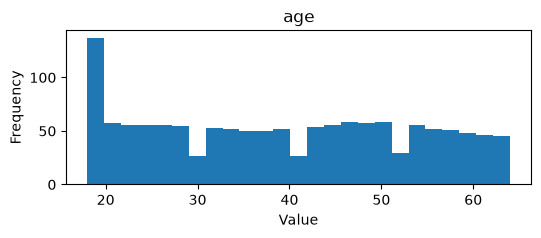

nulls:  0


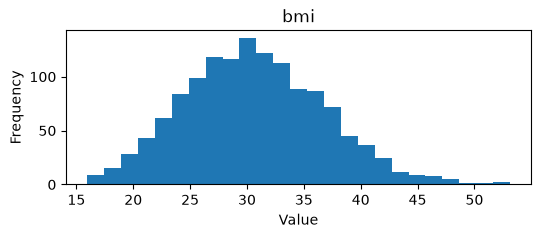

nulls:  0


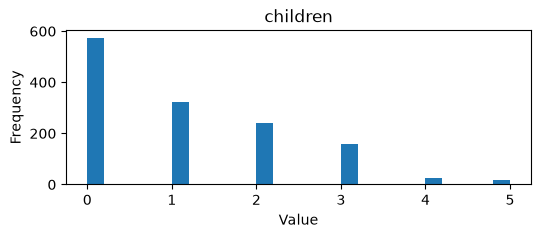

nulls:  0


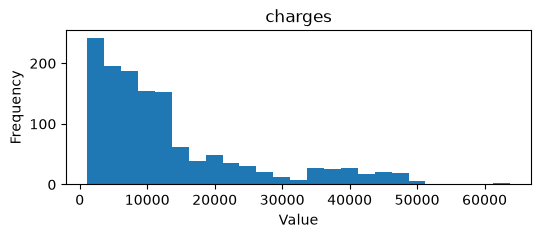

nulls:  0


In [79]:
# Histogram plot using matplot for all numerical variable
# Code derived from Dr Graham West U1_EDA_RealEstate.ipynb github page with little modification

num_cols = data.select_dtypes(exclude=object).columns # Excluding categorical variable

for c in num_cols[:5]:
    ax = data[c].hist(bins=25, figsize=(6,2))
    ax.set_title(c)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.grid(False)
    plt.show()
    print( 'nulls: ', data[c].isna().sum() )
# end

In [80]:
# Nulls seen in the histogram plot for all numerical variable is zero which is indicative of zero missing values

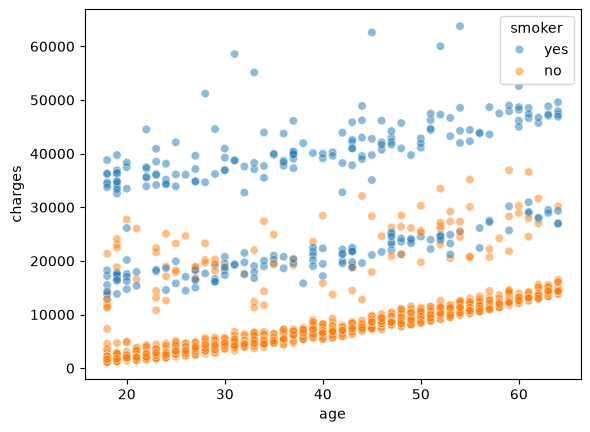

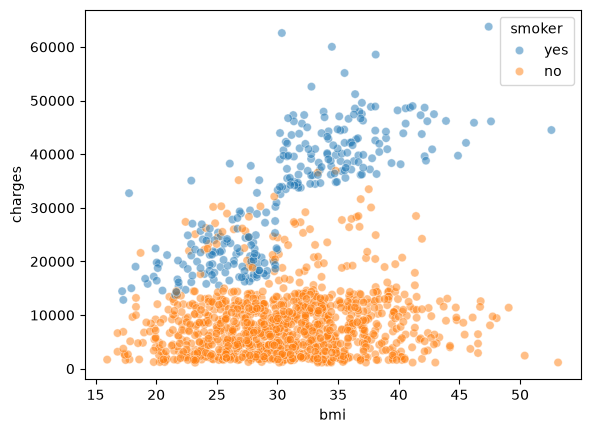

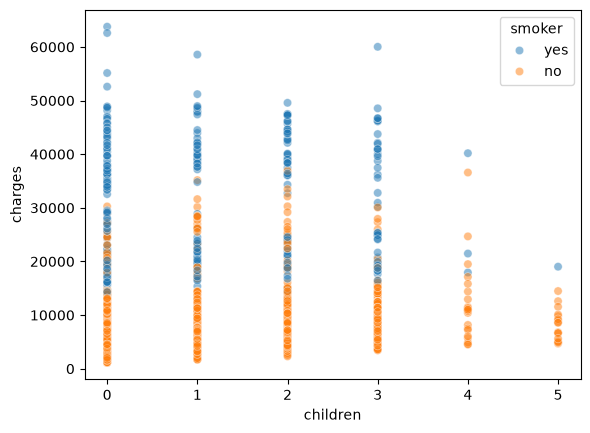

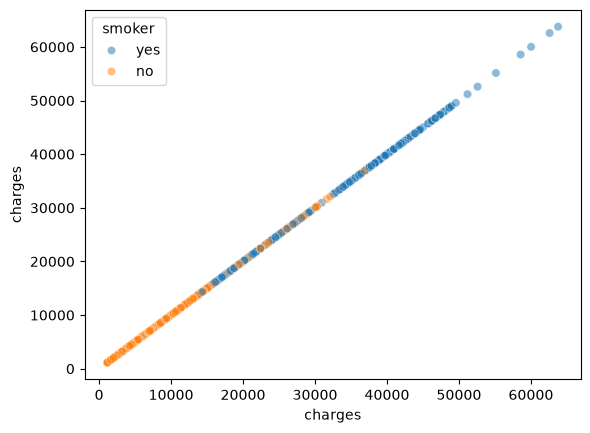

In [81]:
# Scatter plot of numeric column vs charge
# Target value to predict is insurance charge with a hue showing the charge based on a third variable smoking
num_cols = data.select_dtypes(exclude=object).columns

for c in num_cols:
    sns.scatterplot(
        data = data,
        x = c,
        y = 'charges',
        hue = 'smoker',
        alpha = 0.5
    )
    plt.show()

In [82]:
# Correlation heatmap of numerical variable

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


None


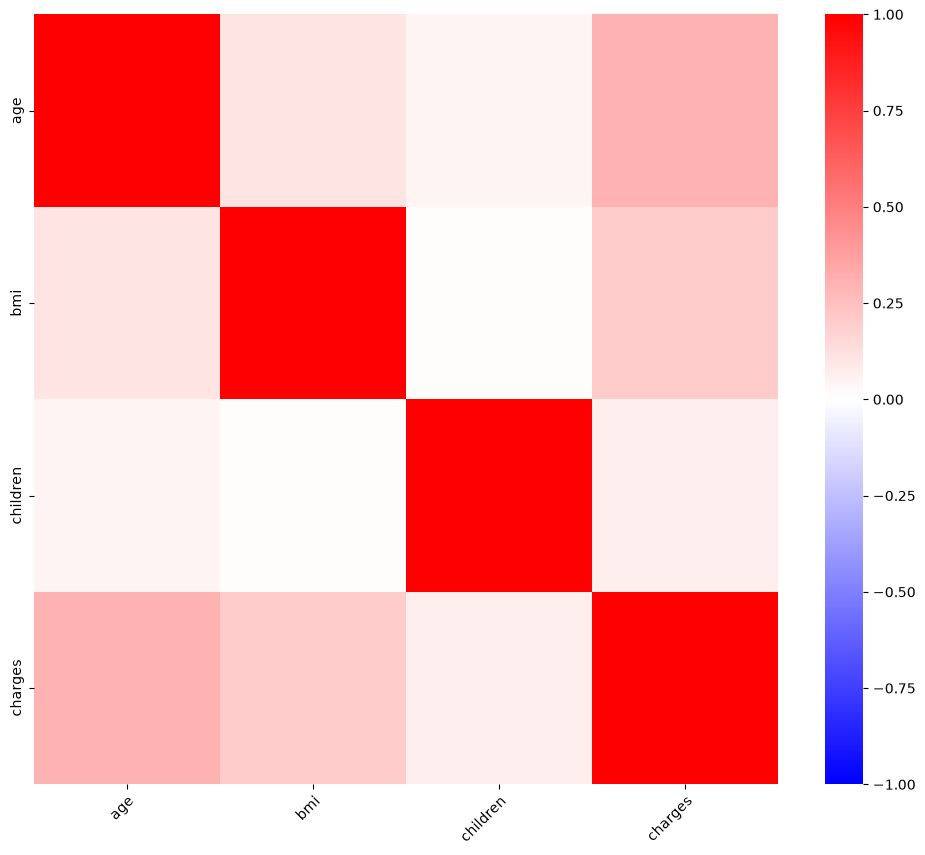

In [83]:
corr = data.select_dtypes(exclude=object).corr() # Excluding categorical variable
print(display(corr))

plt.figure(figsize=(12,10))
sns.heatmap(
    corr,
    vmin=-1,
    vmax=1,
    cmap='bwr'
)
plt.xticks(rotation=45, ha='right', rotation_mode='anchor');

In [84]:
#EDA Categorical Analysis

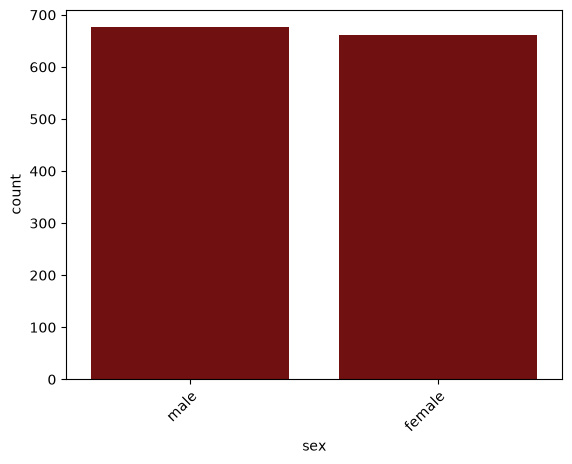

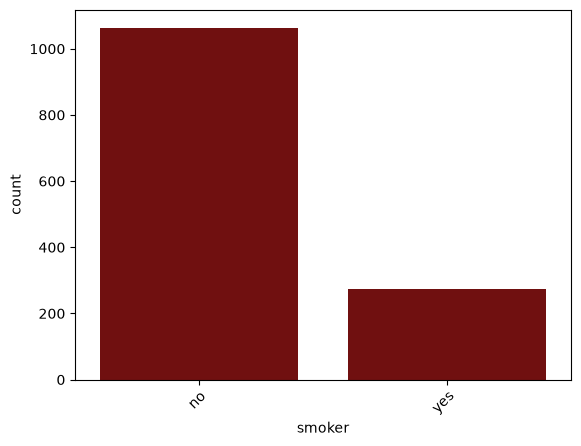

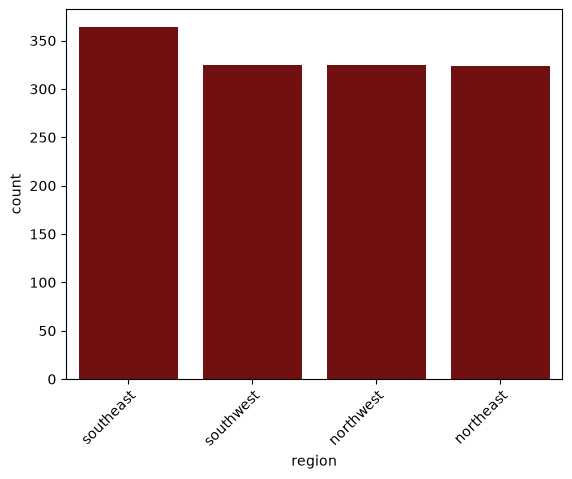

In [85]:
obj_cols = data.select_dtypes(include=object).columns

for c in obj_cols:
    sns.countplot(data, x=c, color='maroon', order=data[c].value_counts().index)
    plt.xticks(rotation=45, ha='right', rotation_mode='anchor')
    plt.show()
# end

In [86]:
#Explore the target charge continuous variable

<Axes: >

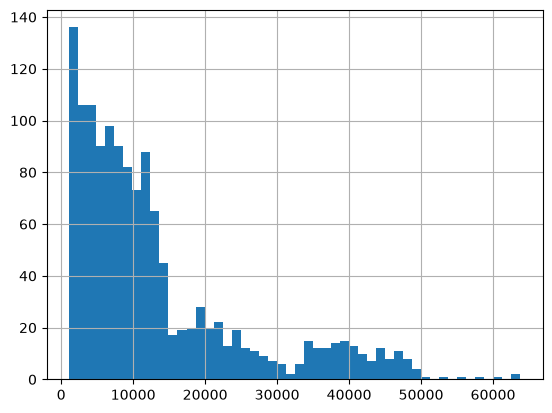

In [87]:
data['charges'].fillna( data['charges'].median() ).hist(bins=50)

# PRE-PROCESSING / CLEANING

In [88]:
#Checking for NAN in the insurance data set
data.isna().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


# No NAN were found in the dataset, so no need to filter NAN or drop NAN

In [89]:
# Information about the insurance data

In [90]:
data.groupby(["charges"])['smoker'].describe()
# Smokers tend to have a higher charges than non smokers

,count,unique,top,freq
charges,,,,
1121.87390,1,1,no,1
1131.50660,1,1,no,1
1135.94070,1,1,no,1
1136.39940,1,1,no,1
1137.01100,1,1,no,1
...,...,...,...,...
55135.40209,1,1,yes,1
58571.07448,1,1,yes,1
60021.39897,1,1,yes,1


# Feature Engineering

In [91]:
# Create new feature
# Goal is to determine smoking status among gender which can be used to detect if bias occur across gender when it comes to insurance charge
data['gender_smoker_status'] = data['sex'].astype(str) + ' ' + data['smoker'].astype(str)
data.head()



,age,sex,bmi,children,smoker,region,charges,gender_smoker_status
0,19,female,27.900,0,yes,southwest,16884.92400,female yes
1,18,male,33.770,1,no,southeast,1725.55230,male no
2,28,male,33.000,3,no,southeast,4449.46200,male no
3,33,male,22.705,0,no,northwest,21984.47061,male no
4,32,male,28.880,0,no,northwest,3866.85520,male no


In [92]:
# Trying to predict the price of insurance so we drop the price column from the dataset
X_data = data.drop(columns=['charges'])
y = data['charges']

In [93]:
# Splitting categorical and numerical variable
# Code derived from Dr Graham West  github page

data_num = X_data.select_dtypes(exclude=object)
data_cat = X_data.select_dtypes(include=object)

In [94]:

#!pip install scikit-learn

,count,mean,std,min,25%,50%,75%,max
age,1338.0,-1.805565e-16,1.000374,-1.509965,-0.869155,-0.014740,0.839674,1.765289
bmi,1338.0,-2.124194e-16,1.000374,-2.412011,-0.716406,-0.043209,0.661157,3.685522
children,1338.0,-5.576008e-17,1.000374,-0.908614,-0.908614,-0.078767,0.751079,3.240619


,age,bmi,children
age,1.000000,0.109272,0.042469
bmi,0.109272,1.000000,0.012759
children,0.042469,0.012759,1.000000


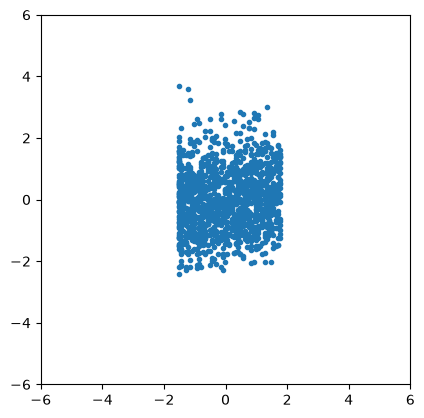

In [95]:

# Code derived from Dr West U2_Reg_Real_Estate.ipynb github page with minor modification

from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
X1_data = scaler.fit_transform(data_num)

df_X1_data = pd.DataFrame(X1_data, columns=data_num.columns)
display(df_X1_data.describe().T)
display(df_X1_data.corr())

plt.plot( X1_data[:,0], X1_data[:,1], '.' )
plt.xlim(-6,6)
plt.ylim(-6,6)
plt.gca().set_aspect('equal')

In [96]:
# Showing split numerical data from the insurance dataset
print(data_num)

      age     bmi  children
0      19  27.900         0
1      18  33.770         1
2      28  33.000         3
3      33  22.705         0
4      32  28.880         0
...   ...     ...       ...
1333   50  30.970         3
1334   18  31.920         0
1335   18  36.850         0
1336   21  25.800         0
1337   61  29.070         0

[1338 rows x 3 columns]


In [97]:
# Showing split categorical data from the insurance dataset
print(data_cat)

         sex smoker     region gender_smoker_status
0     female    yes  southwest           female yes
1       male     no  southeast              male no
2       male     no  southeast              male no
3       male     no  northwest              male no
4       male     no  northwest              male no
...      ...    ...        ...                  ...
1333    male     no  northwest              male no
1334  female     no  northeast            female no
1335  female     no  southeast            female no
1336  female     no  southwest            female no
1337  female    yes  northwest           female yes

[1338 rows x 4 columns]


In [98]:
# Performing standard scaler on the numerical variable

# Creating dummies for Insurance Dataset to convert to numerical data for ML

In [99]:
# Code derived from Dr West U2_Reg_Real_Estate.ipynb github page with minor modificiation

data_dum = pd.DataFrame()
for c in data_cat.columns:
    dummy = pd.get_dummies(data_cat[c], prefix=c, dtype=int)
    dummy_sum = dummy.sum(axis=0)
    col_to_drop = dummy_sum.idxmax()
    dummy = dummy.drop(columns=[col_to_drop])
    data_dum = pd.concat([data_dum, dummy], axis=1)
# end
data_dum.head()

,sex_female,smoker_yes,region_northeast,region_northwest,region_southwest,gender_smoker_status_female yes,gender_smoker_status_male no,gender_smoker_status_male yes
0,1,1,0,0,1,1,0,0
1,0,0,0,0,0,0,1,0
2,0,0,0,0,0,0,1,0
3,0,0,0,1,0,0,1,0
4,0,0,0,1,0,0,1,0


# RUNNING MODELS

In [100]:
X = pd.concat([df_X1_data, data_dum], axis=1)
X.head()

,age,bmi,children,sex_female,smoker_yes,region_northeast,region_northwest,region_southwest,gender_smoker_status_female yes,gender_smoker_status_male no,gender_smoker_status_male yes
0,-1.438764,-0.453320,-0.908614,1,1,0,0,1,1,0,0
1,-1.509965,0.509621,-0.078767,0,0,0,0,0,0,1,0
2,-0.797954,0.383307,1.580926,0,0,0,0,0,0,1,0
3,-0.441948,-1.305531,-0.908614,0,0,0,1,0,0,1,0
4,-0.513149,-0.292556,-0.908614,0,0,0,1,0,0,1,0


In [101]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

models = [
    LinearRegression(),
    KNeighborsRegressor(n_neighbors=1, weights='uniform'),
    KNeighborsRegressor(n_neighbors=10, weights='uniform'),
    KNeighborsRegressor(n_neighbors=100, weights='uniform'),
    DecisionTreeRegressor(max_depth=2),
    DecisionTreeRegressor(max_depth=5),
    DecisionTreeRegressor(max_depth=10),
    RandomForestRegressor(n_estimators=10, max_depth=5),
    RandomForestRegressor(n_estimators=100, max_depth=10),
    GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=2),
]

# Cross Validation

In [102]:
from sklearn.model_selection import cross_val_score, KFold

kf = KFold(n_splits=5, shuffle=True)

X.columns = X.columns.astype(str) # Convert column names to strings

for m in models:
    print(m)

    cv_scores = -cross_val_score(m, X, y, cv=kf, scoring='neg_mean_absolute_percentage_error')
    cv_scores = pd.DataFrame(cv_scores)
    display(cv_scores.describe().T)

    print()
# end

LinearRegression()


,count,mean,std,min,25%,50%,75%,max
0,5.0,0.419438,0.027588,0.393528,0.403347,0.409556,0.427072,0.463689



KNeighborsRegressor(n_neighbors=1)


,count,mean,std,min,25%,50%,75%,max
0,5.0,0.38062,0.071939,0.313823,0.343303,0.347252,0.403085,0.495636



KNeighborsRegressor(n_neighbors=10)


...

,count,mean,std,min,25%,50%,75%,max
0,5.0,0.292205,0.011596,0.27473,0.286007,0.298217,0.300044,0.302026



RandomForestRegressor(max_depth=10)


,count,mean,std,min,25%,50%,75%,max
0,5.0,0.305671,0.03309,0.253103,0.299547,0.309855,0.326777,0.339074



GradientBoostingRegressor(max_depth=2)


,count,mean,std,min,25%,50%,75%,max
0,5.0,0.288231,0.024317,0.268329,0.272849,0.284835,0.285514,0.329628


#GRID SEARCH CROSS VALIDATION

Grid Search: Selects hyperparameters that minimize cross-validated error.

In [103]:
!pip install xgboost

In [104]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

# Define models and their parameter grids
param_grids = {
    "KNeighborsRegressor": (
        KNeighborsRegressor(),
        {
            "n_neighbors": [1, 5, 10, 20, 50],
            "weights": ["uniform", "distance"]
        }
    ),

    "RandomForestRegressor": (
        RandomForestRegressor(),
        {
            "n_estimators": [10, 50, 100],
            "max_depth": [3, 5, 10],
            "min_samples_split": [2, 5, 10],
            'min_samples_leaf': [1, 2, 5, 10]
        }
    ),

    "GradientBoostingRegressor": (
        GradientBoostingRegressor(),
        {
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.01, 0.1, 0.2],
            "max_depth": [2, 3, 5],
            'min_samples_leaf': [1, 2, 5, 10]
        }
    ),

    "DecisionTreeRegressor": (
        DecisionTreeRegressor(),
        {
            "max_depth": [2, 3, 5, 10],
            "min_samples_split": [2, 5, 10],
            'min_samples_leaf': [1, 2, 5, 10]
        }
    ),

    "LinearRegression": (
        LinearRegression(),
        {
            "fit_intercept": [True, False],
        }
    ),

    "XGBRegressor": (
        XGBRegressor(random_state=42),
        {
            'n_estimators': [50, 100, 200],
            'learning_rate': [0.01, 0.1, 0.2],
            'max_depth': [3, 5, 7],
            'subsample': [0.7, 0.9, 1.0],
            'colsample_bytree': [0.7, 0.9, 1.0]
        }
    ),

  }

# Define cross-validation strategy
kf = KFold(n_splits=5, shuffle=True)

X.columns = X.columns.astype(str) # Convert column names to strings

# Store results
results = []

# Perform GridSearchCV for each model
for name, (model, param_grid) in param_grids.items():
    print(f"Performing GridSearchCV for {name}...")

    grid_search = GridSearchCV(model, param_grid, cv=kf, scoring="neg_mean_absolute_percentage_error", n_jobs=-1)
    grid_search.fit(X, y)

    best_params = grid_search.best_params_
    best_score = grid_search.best_score_

    results.append({"Model": name, "Best Score": best_score, "Best Params": best_params})
# end

results

Performing GridSearchCV for KNeighborsRegressor...
Performing GridSearchCV for RandomForestRegressor...
Performing GridSearchCV for GradientBoostingRegressor...
Performing GridSearchCV for DecisionTreeRegressor...
Performing GridSearchCV for LinearRegression...
Performing GridSearchCV for XGBRegressor...


[{'Model': 'KNeighborsRegressor',
  'Best Score': np.float64(-0.3319483723884936),
  'Best Params': {'n_neighbors': 10, 'weights': 'distance'}},
 {'Model': 'RandomForestRegressor',
  'Best Score': np.float64(-0.27527825068482437),
  'Best Params': {'max_depth': 10,
   'min_samples_leaf': 10,
   'min_samples_split': 2,
   'n_estimators': 10}},
 {'Model': 'GradientBoostingRegressor',
  'Best Score': np.float64(-0.2772146806254282),
  'Best Params': {'learning_rate': 0.2,
   'max_depth': 2,
   'min_samples_leaf': 1,
   'n_estimators': 100}},
 {'Model': 'DecisionTreeRegressor',
  'Best Score': np.float64(-0.2994291405110965),
  'Best Params': {'max_depth': 5,
   'min_samples_leaf': 5,
   'min_samples_split': 10}},
 {'Model': 'LinearRegression',
  'Best Score': np.float64(-0.4224386137942517),
  'Best Params': {'fit_intercept': False}},
 {'Model': 'XGBRegressor',
  'Best Score': np.float64(-0.27676382805181066),
  'Best Params': {'colsample_bytree': 1.0,
   'learning_rate': 0.1,
   'max_dep

#Parsimony

In [105]:
#We have few features so there is no need to remove excess feature but we can view the importance of the prediction

In [106]:
# Fit a Random Forest model
rf = RandomForestRegressor(n_estimators=1000)
rf.fit(X, y)

# Get feature importances
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
importances = importances[:10]

features_rf = importances.index

X_pars = X[ features_rf ]
importances

,0
smoker_yes,0.619967
bmi,0.210002
age,0.129527
children,0.018863
region_northwest,0.005690
region_northeast,0.005384
region_southwest,0.003605
sex_female,0.003301
gender_smoker_status_male no,0.003186
gender_smoker_status_male yes,0.000255


In [107]:
# From running the feature importance, smoking was shown to have the strongest predictor for insurance charge, followed next by bmi charge and age

#Visualizing Corrlelation of features

                               gender_smoker_status_male no  sex_female  \
gender_smoker_status_male no                       1.000000   -0.785289   
sex_female                                        -0.785289    1.000000   
gender_smoker_status_male yes                     -0.291417   -0.363410   
smoker_yes                                        -0.402697   -0.076185   
region_northwest                                   0.022982    0.011156   
region_northeast                                  -0.000691    0.002425   
region_southwest                                   0.001506    0.004184   
bmi                                                0.013953   -0.046371   
age                                               -0.008200    0.020856   
children                                          -0.001366   -0.017163   

                               gender_smoker_status_male yes  smoker_yes  \
gender_smoker_status_male no                       -0.291417   -0.402697   
sex_female            

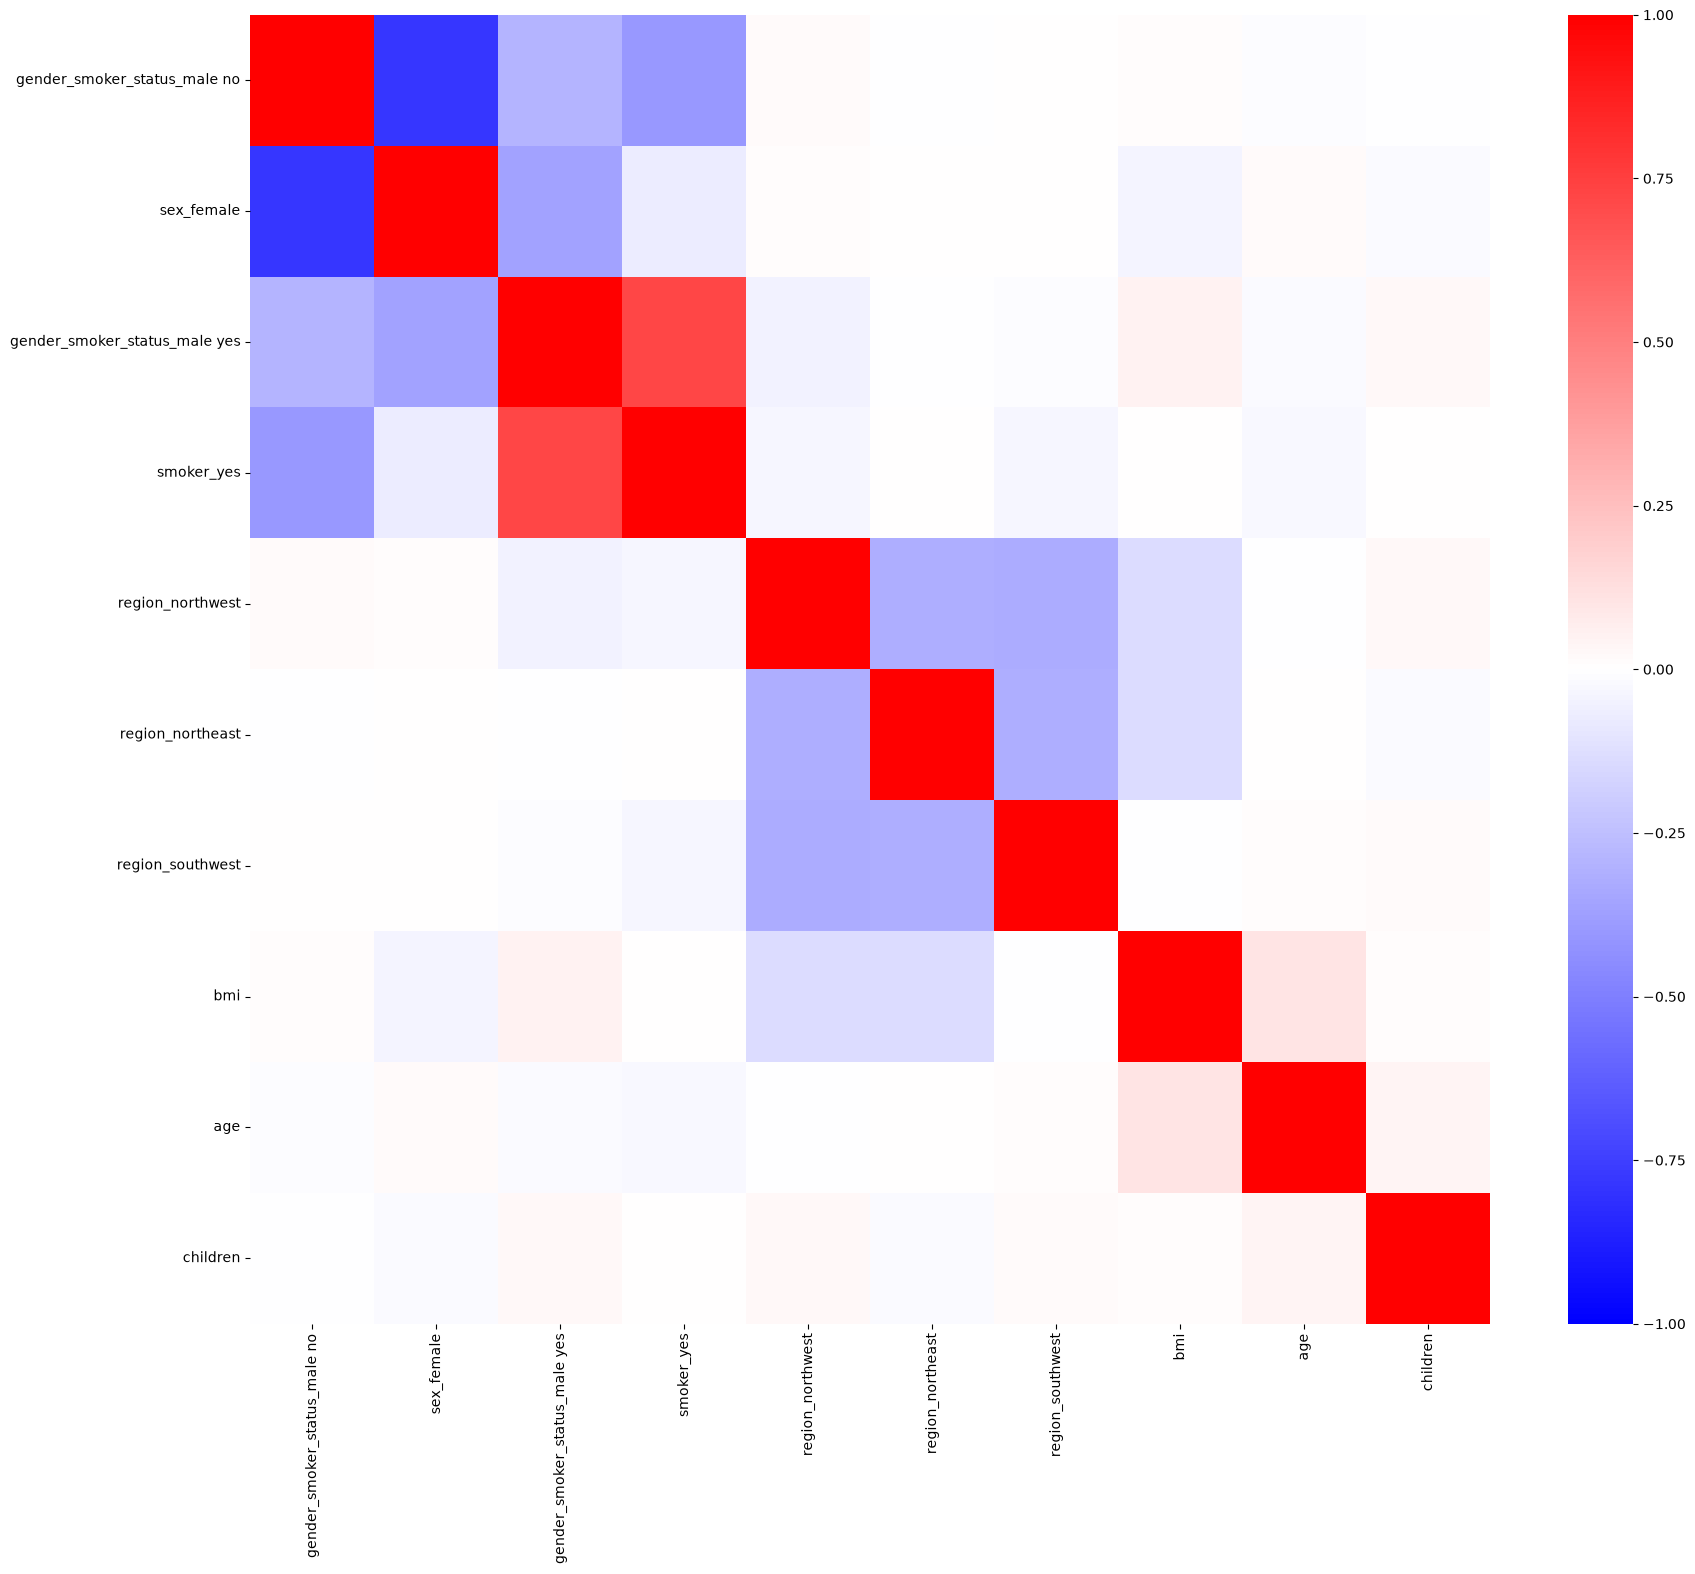

In [108]:
corr = X_pars.corr()

# Sort columns by correlation for easy visuals
total_r2 = (corr**2).sum().sort_values(ascending=False)
sorted_columns = total_r2.index
corr = corr.loc[sorted_columns, sorted_columns]

plt.figure(figsize=(20, 17))
sns.heatmap(
    corr,
    vmin=-1,
    vmax=1,
    cmap='bwr'
)

print(corr)

# Variance inflation factor (VIF) to detect multicollinearity among independent variables

In [109]:
!pip install statsmodels

In [110]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

X_pars_with_const = sm.add_constant(X_pars)

vif = pd.Series(
    [variance_inflation_factor(X_pars_with_const.values, i) for i in range(X_pars_with_const.shape[1])],
    index=X_pars_with_const.columns
).sort_values(ascending=False)

vif[:10]

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,0
sex_female,inf
gender_smoker_status_male yes,inf
gender_smoker_status_male no,inf
smoker_yes,2.305494
region_northwest,1.536485
region_northeast,1.531066
region_southwest,1.483610
bmi,1.109316
age,1.016822
children,1.004826


In [111]:
# New Engineered features had perfect infinity which means multicolinearity exist, one variable affects the other.

In [112]:
# Re-fitting models after testing for multi-colinearity to drop highest VIF

In [113]:
# Copy dataset to avoid modifying the original
X_vif = X_pars.copy()
while True:
  X_vif_with_const = sm.add_constant(X_vif)

  # Compute VIF for all features
  vif_series = pd.Series(
  [variance_inflation_factor(X_vif_with_const.values, i) for i in range(X_vif_with_const.shape[1])],
  index=X_vif_with_const.columns
    )
  #Exclude constant term
  vif_series = vif_series.drop('const', errors='ignore')
  highest_vif_feature = vif_series.idxmax()
  # Break the loop if all features have VIF ≤ 10
  if vif_series.loc[highest_vif_feature] <= 10:  # Checking the first feature after 'const'
    break

  # Drop the feature with the highest VIF
  X_vif = X_vif.drop(columns=[highest_vif_feature])

  print(f"Dropped: {highest_vif_feature} (VIF={vif_series.loc[highest_vif_feature]:.2f})")
  # end


vif_series[:25]

Dropped: sex_female (VIF=inf)


/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,0
smoker_yes,2.305494
bmi,1.109316
age,1.016822
children,1.004826
region_northwest,1.536485
region_northeast,1.531066
region_southwest,1.483610
gender_smoker_status_male no,1.194794
gender_smoker_status_male yes,2.114522


In [114]:
# Most of the VIF of the features hovers around 1 (including the target variablee which is 2.3) after dropping featured engineer variable which indicates that the variables are not correlated among each other.

In [115]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

# Define models and their parameter grids
param_grids = {
    "KNeighborsRegressor": (
        KNeighborsRegressor(),
        {
            "n_neighbors": [1, 5, 10, 20, 50],
            "weights": ["uniform", "distance"]
        }
    ),

    "RandomForestRegressor": (
        RandomForestRegressor(),
        {
            "n_estimators": [10, 50, 100],
            "max_depth": [3, 5, 10],
            "min_samples_split": [2, 5, 10],
            'min_samples_leaf': [1, 2, 5, 10]
        }
    ),

    "GradientBoostingRegressor": (
        GradientBoostingRegressor(),
        {
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.01, 0.1, 0.2],
            "max_depth": [2, 3, 5],
            'min_samples_leaf': [1, 2, 5, 10]
        }
    ),

    "DecisionTreeRegressor": (
        DecisionTreeRegressor(),
        {
            "max_depth": [2, 3, 5, 10],
            "min_samples_split": [2, 5, 10],
            'min_samples_leaf': [1, 2, 5, 10]
        }
    ),

    "LinearRegression": (
        LinearRegression(),
        {
            "fit_intercept": [True, False],
        }
    ),

    "XGBRegressor": (
        XGBRegressor(random_state=42),
        {
            'n_estimators': [50, 100, 200],
            'learning_rate': [0.01, 0.1, 0.2],
            'max_depth': [3, 5, 7],
            'subsample': [0.7, 0.9, 1.0],
            'colsample_bytree': [0.7, 0.9, 1.0]
        }
    ),
  }

# Define cross-validation strategy
kf = KFold(n_splits=5, shuffle=True)

X.columns = X.columns.astype(str) # Convert column names to strings

# Store results
results = []

# Perform GridSearchCV for each model
for name, (model, param_grid) in param_grids.items():
    print(f"Performing GridSearchCV for {name}...")

    grid_search = GridSearchCV(model, param_grid, cv=kf, scoring="neg_mean_absolute_percentage_error", n_jobs=-1)
    grid_search.fit(X_vif, y)

    best_params = grid_search.best_params_
    best_score = grid_search.best_score_

    results.append({"Model": name, "Best Score": best_score, "Best Params": best_params})
# end

results

Performing GridSearchCV for KNeighborsRegressor...
Performing GridSearchCV for RandomForestRegressor...
Performing GridSearchCV for GradientBoostingRegressor...
Performing GridSearchCV for DecisionTreeRegressor...
Performing GridSearchCV for LinearRegression...
Performing GridSearchCV for XGBRegressor...


[{'Model': 'KNeighborsRegressor',
  'Best Score': np.float64(-0.34116105111404754),
  'Best Params': {'n_neighbors': 5, 'weights': 'distance'}},
 {'Model': 'RandomForestRegressor',
  'Best Score': np.float64(-0.2804550940477827),
  'Best Params': {'max_depth': 10,
   'min_samples_leaf': 10,
   'min_samples_split': 2,
   'n_estimators': 10}},
 {'Model': 'GradientBoostingRegressor',
  'Best Score': np.float64(-0.28393763656650806),
  'Best Params': {'learning_rate': 0.2,
   'max_depth': 2,
   'min_samples_leaf': 10,
   'n_estimators': 50}},
 {'Model': 'DecisionTreeRegressor',
  'Best Score': np.float64(-0.3027680313593686),
  'Best Params': {'max_depth': 5,
   'min_samples_leaf': 2,
   'min_samples_split': 5}},
 {'Model': 'LinearRegression',
  'Best Score': np.float64(-0.4222539188096599),
  'Best Params': {'fit_intercept': True}},
 {'Model': 'XGBRegressor',
  'Best Score': np.float64(-0.28022886742845105),
  'Best Params': {'colsample_bytree': 1.0,
   'learning_rate': 0.2,
   'max_depth

In [116]:
pip install xgboost

# Deep Learning - KERAS

# Performing KERAS Cross Validation

In [117]:
! pip install keras
! pip install tensorflow

In [118]:
from keras.models import Sequential
from keras.layers import *
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay, PolynomialDecay
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

def build_model( X_train, epochs, batch_size, decay_frac, initial_learning_rate, dropout_rate ):

    # Create model
    model = Sequential([
        Input(shape=X_train.shape[1]),
        Dense(20, activation='relu'),
        Dropout(dropout_rate),
        Dense(20, activation='relu'),
        Dropout(dropout_rate),
        Dense(20, activation='relu'),
        Dense(1, activation='relu'),
    ])

    # define training parameters
    decay_epochs    = int( epochs * decay_frac )
    n_train         = X_train.shape[0]
    steps_per_epoch = int( np.ceil( n_train / batch_size ) )
    decay_steps     = decay_epochs * steps_per_epoch

    lr_schedule_poly = PolynomialDecay(
        initial_learning_rate=initial_learning_rate,
        end_learning_rate=0.001,
        decay_steps=decay_steps,
        power=2.0
    )

    # Define the optimizer with a custom learning rate
    optimizer = Adam(
        learning_rate=lr_schedule_poly,
    )

    # Compile model
    model.compile(
        optimizer=optimizer,
        loss='mae'
    )

    return model
# end

In [119]:
#!pip install tensorboard

In [120]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, r2_score

# Re-defining build_model with the fix for the Input layer
from keras.models import Sequential
from keras.layers import *
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay, PolynomialDecay
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

def build_model( X_train, epochs, batch_size, decay_frac, initial_learning_rate, dropout_rate ):

    # Create model
    model = Sequential([
        Input(shape=(X_train.shape[1],)), # FIX: Wrapped X_train.shape[1] in a tuple
        Dense(20, activation='relu'),
        Dropout(dropout_rate),
        Dense(20, activation='relu'),
        Dropout(dropout_rate),
        Dense(20, activation='relu'),
        Dense(1, activation='relu'),
    ])

    # define training parameters
    decay_epochs    = int( epochs * decay_frac )
    n_train         = X_train.shape[0]
    steps_per_epoch = int( np.ceil( n_train / batch_size ) )
    decay_steps     = decay_epochs * steps_per_epoch

    lr_schedule_poly = PolynomialDecay(
        initial_learning_rate=initial_learning_rate,
        end_learning_rate=0.001,
        decay_steps=decay_steps,
        power=2.0
    )

    # Define the optimizer with a custom learning rate
    optimizer = Adam(
        learning_rate=lr_schedule_poly,
    )

    # Compile model
    model.compile(
        optimizer=optimizer,
        loss='mae'
    )

    return model
# end

epochs                = 500
batch_size            = 256
decay_frac            = 0.8
dropout_rate          = 0.25
initial_learning_rate = 0.01

n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True)

train_mae_list = []
test_mae_list = []
train_r2_list = []
test_r2_list = []

fold = 1
for train_index, test_index in kf.split(X):
    print(f"Fold {fold}/{n_splits}")
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Build a fresh model (which resets optimizer state including the learning rate schedule)
    model = build_model(
        X_train,
        epochs,
        batch_size,
        decay_frac,
        initial_learning_rate,
        dropout_rate
    )

    # Early stopping callback
    early_stopping = EarlyStopping(
        monitor='val_loss',  # Monitor validation loss
        patience=100,          # Stop after 5 epochs without improvement
        restore_best_weights=True  # Restore the best weights after stopping
    )

    # Train the model
    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_test, y_test),
        verbose=0,
        callbacks=[early_stopping]
    )

    # Evaluate on training data
    y_train_pred = model.predict(X_train, verbose=0)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_r2 = r2_score(y_train, y_train_pred)

    # Evaluate on test data
    y_test_pred = model.predict(X_test, verbose=0)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    print("MAE:")
    print(f"  Train: {train_mae:.4f}")
    print(f"  Test:  {test_mae:.4f}")
    print("R^2:")
    print(f"  Train: {train_r2:.4f}")
    print(f"  Test:  {test_r2:.4f}")
    print()

    train_mae_list.append(train_mae)
    test_mae_list.append(test_mae)
    train_r2_list.append(train_r2)
    test_r2_list.append(test_r2)

    fold += 1
# end

2026/06/29 18:50:50 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '0a3c1eedc0ad470baeff7abd48a6dae9', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current tensorflow workflow
2026/06/29 18:50:50 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'pandas.core.frame.DataFrame'>. Dataset logging skipped.
2026/06/29 18:50:50 WARNING mlflow.tensorflow: Failed to log training dataset information to MLflow Tracking. Reason: 'DataFrame' object has no attribute 'flatten'


Fold 1/5


2026/06/29 18:51:29 WARNING mlflow.tensorflow: Failed to infer model signature: could not sample data to infer model signature: Cannot log input example or model signature for input with type <class 'pandas.core.frame.DataFrame'>. TensorFlow Keras autologging can only log input examples and model signatures for the following input types: numpy.ndarray, dict[string -> numpy.ndarray], tensorflow.keras.utils.Sequence, and tensorflow.data.Dataset (TensorFlow >= 2.1.0 required)
2026/06/29 18:51:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/29 18:51:29 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


🏃 View run efficient-crab-987 at: http://localhost:5000/#/experiments/2/runs/0a3c1eedc0ad470baeff7abd48a6dae9
🧪 View experiment at: http://localhost:5000/#/experiments/2
MAE:
  Train: 2379.1136
  Test:  2704.8020
R^2:
  Train: 0.8216
  Test:  0.7824

Fold 2/5


2026/06/29 18:51:34 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '26b64bd00cff4adc8b2a384f61fd944c', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current tensorflow workflow
2026/06/29 18:51:34 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'pandas.core.frame.DataFrame'>. Dataset logging skipped.
2026/06/29 18:51:34 WARNING mlflow.tensorflow: Failed to log training dataset information to MLflow Tracking. Reason: 'DataFrame' object has no attribute 'flatten'


...

2026/06/29 18:53:27 WARNING mlflow.tensorflow: Failed to infer model signature: could not sample data to infer model signature: Cannot log input example or model signature for input with type <class 'pandas.core.frame.DataFrame'>. TensorFlow Keras autologging can only log input examples and model signatures for the following input types: numpy.ndarray, dict[string -> numpy.ndarray], tensorflow.keras.utils.Sequence, and tensorflow.data.Dataset (TensorFlow >= 2.1.0 required)
2026/06/29 18:53:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/29 18:53:28 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
2026/06/29 18:53:33 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'e5e5f271a36e475bab6c258dd2294b5d', which will track h

🏃 View run intelligent-calf-699 at: http://localhost:5000/#/experiments/2/runs/94123cfd758d4842ad20cad3f3cf0d9f
🧪 View experiment at: http://localhost:5000/#/experiments/2
MAE:
  Train: 2110.8992
  Test:  2547.0129
R^2:
  Train: 0.8295
  Test:  0.8151

Fold 5/5


2026/06/29 18:53:33 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'pandas.core.frame.DataFrame'>. Dataset logging skipped.
2026/06/29 18:53:33 WARNING mlflow.tensorflow: Failed to log training dataset information to MLflow Tracking. Reason: 'DataFrame' object has no attribute 'flatten'


2026/06/29 18:54:11 WARNING mlflow.tensorflow: Failed to infer model signature: could not sample data to infer model signature: Cannot log input example or model signature for input with type <class 'pandas.core.frame.DataFrame'>. TensorFlow Keras autologging can only log input examples and model signatures for the following input types: numpy.ndarray, dict[string -> numpy.ndarray], tensorflow.keras.utils.Sequence, and tensorflow.data.Dataset (TensorFlow >= 2.1.0 required)
2026/06/29 18:54:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/29 18:54:11 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


🏃 View run clean-mare-844 at: http://localhost:5000/#/experiments/2/runs/e5e5f271a36e475bab6c258dd2294b5d
🧪 View experiment at: http://localhost:5000/#/experiments/2
MAE:
  Train: 2193.9189
  Test:  1966.5359
R^2:
  Train: 0.8296
  Test:  0.8245



In [121]:
results_df = pd.DataFrame({
    'Train MAE': train_mae_list,
    'Test MAE': test_mae_list,
    'Train R2': train_r2_list,
    'Test R2': test_r2_list
})

results_df.describe()

,Train MAE,Test MAE,Train R2,Test R2
count,5.000000,5.000000,5.000000,5.000000
mean,2214.147507,2278.049707,0.825571,0.819669
std,101.397915,339.125254,0.005765,0.028762
min,2110.899173,1954.194096,0.817347,0.782365
25%,2161.920726,1966.535864,0.821607,0.813828
50%,2193.918881,2217.703611,0.829481,0.815121
75%,2224.885195,2547.012915,0.829593,0.824470
max,2379.113559,2704.802050,0.829829,0.862559


# Train test split

In [122]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_vif, y,
                                                    test_size=0.2)

# Ensure train/test label distributions are as similar as possible (stratification for regression)

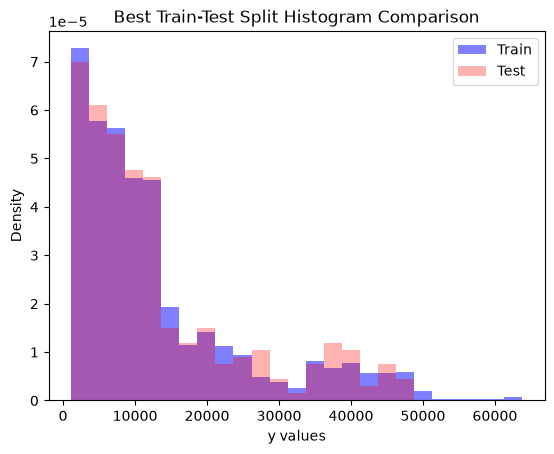

In [123]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error


# Define the number of attempts
attempts = 1000

# Determine the global min and max of y
y_min, y_max = y.min(), y.max()
bins = np.linspace(y_min, y_max, 26)  # 25 bins means 26 edges

best_mse = float('inf')
best_split = None

for i in range(attempts):
    # Perform train-test split
    X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(X_vif, y, test_size=0.2)

    # Compute histograms
    y_train_hist, _ = np.histogram(y_train_i, bins=bins, density=True)
    y_test_hist, _ = np.histogram(y_test_i, bins=bins, density=True)

    # Compute MSE between histograms
    mse = mean_squared_error(y_train_hist, y_test_hist)

    # Save the best split
    if mse < best_mse:
        best_mse = mse
        best_split = (X_train_i, X_test_i, y_train_i, y_test_i)

# Unpack the best split
X_train, X_test, y_train, y_test = best_split

# Display histograms of the best split
plt.hist(y_train, bins=bins, alpha=0.5, color='b', label='Train', density=True)
plt.hist(y_test, bins=bins, alpha=0.3, color='r', label='Test', density=True)
plt.legend()
plt.xlabel('y values')
plt.ylabel('Density')
plt.title('Best Train-Test Split Histogram Comparison')
plt.show()

# Create Model

In [124]:
from keras.models import Sequential
from keras.layers import *
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

dropout_rate = 0.1

# Create model
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(20, activation='relu'),
    BatchNormalization(),
    Dropout(dropout_rate),
    Dense(20, activation='relu'),
    BatchNormalization(),
    Dropout(dropout_rate),
    Dense(20, activation='relu'),
    Dense(1, activation='relu'),
])

# Define the optimizer with a custom learning rate
optimizer = Adam(learning_rate=0.01)

# Compile model
model.compile(
    optimizer=optimizer,
    loss='mae'
)

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=100,          # Stop after 5 epochs without improvement
    restore_best_weights=True  # Restore the best weights after stopping
)

# Display model summary
model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_44 (Dense)                │ (None, 20)             │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 20)             │            80 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 20)             │            80 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,221 (4.77 KB)

 Trainable params: 1,141 (4.46 KB)

 Non-trainable params: 80 (320.00 B)

# Create learning rate schedule

In [125]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay, PolynomialDecay

# define training parameters
epochs          = 500
batch_size      = 256
decay_epochs    = int( epochs * 0.5 )

n_train         = X_train.shape[0]
steps_per_epoch = int( np.ceil( n_train / batch_size ) )
decay_steps     = decay_epochs * steps_per_epoch
#print(decay_steps)

# Define the learning rate schedule
initial_learning_rate = 0.05

lr_schedule_exp = ExponentialDecay(
    initial_learning_rate=initial_learning_rate,
    decay_rate=5.0,
    decay_steps=decay_steps
)

lr_schedule_poly = PolynomialDecay(
    initial_learning_rate=initial_learning_rate,
    end_learning_rate=0.001,
    decay_steps=decay_steps,
    power=1.0
)

# Define the optimizer with a custom learning rate
optimizer = Adam(
    learning_rate=initial_learning_rate,
    #learning_rate=lr_schedule_exp,
    #learning_rate=lr_schedule_poly,
    #clipnorm=1,
    #clipvalue=1,
)

# Compile model
model.compile(
    optimizer=optimizer,
    loss='mae'
)

# Add early stopping and learning rate reduction callbacks

In [126]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=50,          # Stop after 5 epochs without improvement
    restore_best_weights=True  # Restore the best weights after stopping
)

# Callback to reduce LR when a monitored metric has stopped improving
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',       # metric to monitor
    factor=0.5,               # factor by which to reduce the LR
    patience=50,              # number of epochs with no improvement after which LR will be reduced
    min_lr=1e-6,              # lower bound on the learning rate
    verbose=1                 # print when LR is reduced
)

# Train model

In [127]:
# Train model
history = model.fit(
    X_train, y_train,
    epochs=300,
    batch_size=batch_size,
    shuffle=True,
    validation_data=(X_test, y_test),
    verbose=1,
    callbacks=[
        early_stopping,
        #reduce_lr
    ]
)

2026/06/29 18:54:17 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'cfb1a89cd45648d2841d228dd25c2311', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current tensorflow workflow
2026/06/29 18:54:17 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'pandas.core.frame.DataFrame'>. Dataset logging skipped.
2026/06/29 18:54:17 WARNING mlflow.tensorflow: Failed to log training dataset information to MLflow Tracking. Reason: 'DataFrame' object has no attribute 'flatten'


Epoch 1/300
1/5 ━━━━━━━━━━━━━━━━━━━━ 3s 921ms/step - loss: 13980.1279

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 13260.0586 - val_loss: 13284.2812
Epoch 2/300
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 14065.8711

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 13237.7910 - val_loss: 13220.9111
Epoch 3/300
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 13213.5264

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 13174.0322 - val_loss: 13077.6650
Epoch 4/300
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 13921.9258

...

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 2545.6169 - val_loss: 2309.9539
Epoch 171/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 2506.6277 - val_loss: 2583.3372
Epoch 172/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2441.1899 - val_loss: 2438.0840
Epoch 173/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2350.7144 - val_loss: 2437.4336
Epoch 174/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2440.7380 - val_loss: 2447.2375
Epoch 175/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2396.8286 - val_loss: 2528.2671
Epoch 176/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2485.6965 - val_loss: 2853.9170
Epoch 177/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2560.6355 - val_loss: 2804.8550
Epoch 178/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 2573.3860 - val_loss: 2570.0466
Epoch 179/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2436.5881 - val_loss: 2468.0344
Epoch 180/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 2349.8584 - val_loss: 2487.4592
Ep

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 2520.9333 - val_loss: 2269.4067
Epoch 205/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2329.3105 - val_loss: 2520.8809
Epoch 206/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2191.0891 - val_loss: 2925.2966
Epoch 207/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2581.5164 - val_loss: 2684.5303
Epoch 208/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2247.5813 - val_loss: 2688.0496
Epoch 209/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2328.8684 - val_loss: 2714.5522
Epoch 210/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2219.1011 - val_loss: 2314.2671
Epoch 211/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2380.8093 - val_loss: 2510.1526
Epoch 212/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2353.3901 - val_loss: 2680.0642
Epoch 213/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2341.6853 - val_loss: 2717.8579
Epoch 214/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2366.9324 - val_loss: 2657.7573
Ep

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 2351.2261 - val_loss: 2247.4395
Epoch 226/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2569.9197 - val_loss: 2317.3459
Epoch 227/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2478.7856 - val_loss: 2318.1418
Epoch 228/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2472.4468 - val_loss: 2695.6765
Epoch 229/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2459.2695 - val_loss: 2409.3174
Epoch 230/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2361.6924 - val_loss: 2404.0676
Epoch 231/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2394.0464 - val_loss: 2352.2078
Epoch 232/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2318.2246 - val_loss: 2564.1726
Epoch 233/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2573.5173 - val_loss: 2501.3064
Epoch 234/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2376.7932 - val_loss: 2629.3672
Epoch 235/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2323.3774 - val_loss: 2767.0032
Ep

2026/06/29 18:54:38 WARNING mlflow.tensorflow: Failed to infer model signature: could not sample data to infer model signature: Cannot log input example or model signature for input with type <class 'pandas.core.frame.DataFrame'>. TensorFlow Keras autologging can only log input examples and model signatures for the following input types: numpy.ndarray, dict[string -> numpy.ndarray], tensorflow.keras.utils.Sequence, and tensorflow.data.Dataset (TensorFlow >= 2.1.0 required)
2026/06/29 18:54:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/29 18:54:38 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


🏃 View run sneaky-loon-325 at: http://localhost:5000/#/experiments/2/runs/cfb1a89cd45648d2841d228dd25c2311
🧪 View experiment at: http://localhost:5000/#/experiments/2


34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


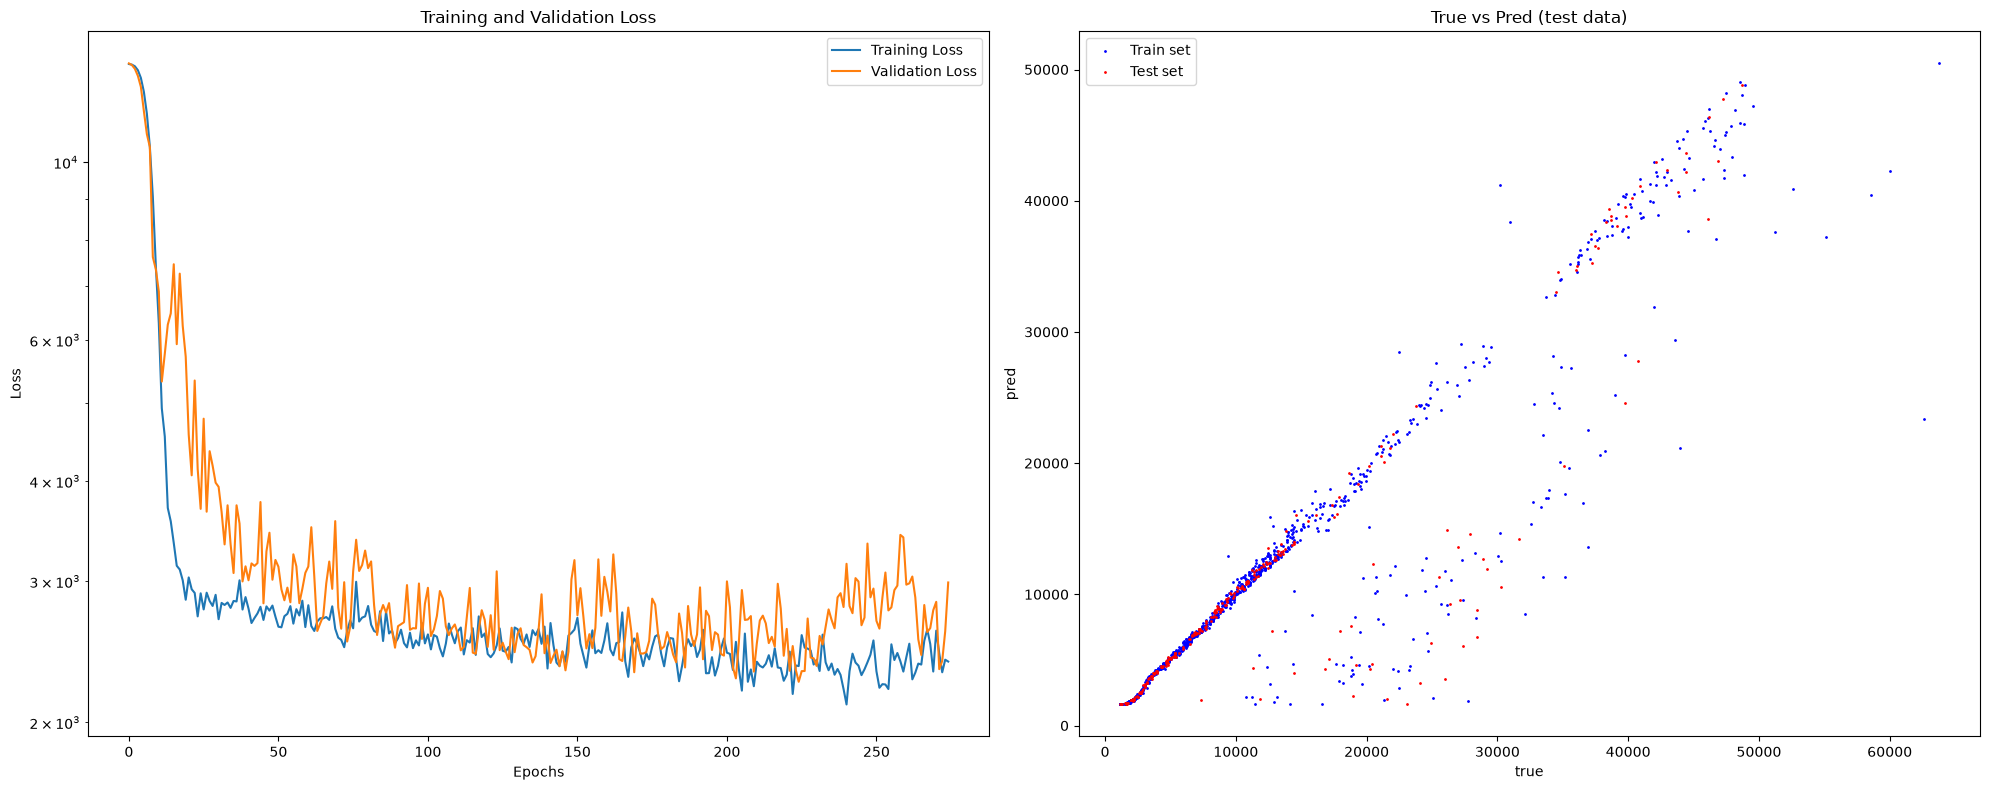

MAE:
  Train: 1754.8388
  Test:  2247.4394
R^2:
  Train: 0.8442
  Test:  0.7677


In [128]:
from sklearn.metrics import mean_absolute_error, r2_score

# Get predictions
y_train_pred = model.predict(X_train)[:,0]
y_test_pred  = model.predict(X_test)[:,0]

# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Left subplot: Training and Validation Loss
axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_yscale('log')
axes[0].set_title('Training and Validation Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Right subplot: True vs Predicted Data
axes[1].scatter(y_train, y_train_pred, c='b', s=1, label="Train set")
axes[1].scatter(y_test, y_test_pred, c='r', s=1, label="Test set")
axes[1].set_title('True vs Pred (test data)')
axes[1].set_xlabel('true')
axes[1].set_ylabel('pred')
axes[1].legend()

plt.tight_layout()
plt.show()

mae_train = mean_absolute_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

print("MAE:")
print(f"  Train: {mae_train:.4f}")
print(f"  Test:  {mae_test:.4f}")
print("R^2:")
print(f"  Train: {r2_train:.4f}")
print(f"  Test:  {r2_test:.4f}")

In [129]:
import pickle

# Save the Keras model in the native Keras format
model.save('insurance_model.keras')
print("Model saved as insurance_model.keras")

# Save the StandardScaler used for X_data (scalar x)
# The 'scaler' object was defined earlier in the notebook
with open('scaler_x.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("StandardScaler (for X) saved as scaler_x.pkl")

# Note: The 'y' target variable (charges) was not explicitly scaled in the notebook.


Model saved as insurance_model.keras
StandardScaler (for X) saved as scaler_x.pkl


# Comparison with other model

In [130]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor

# Define regression models corresponding to the original classifiers
models = [
    LinearRegression(),
    KNeighborsRegressor(n_neighbors=5, weights='uniform'),
    KNeighborsRegressor(n_neighbors=10, weights='uniform'),
    KNeighborsRegressor(n_neighbors=50, weights='uniform'),
    RandomForestRegressor(n_estimators=100, max_leaf_nodes=3),
    RandomForestRegressor(n_estimators=100, max_leaf_nodes=10),
    RandomForestRegressor(n_estimators=100, max_leaf_nodes=30),
    GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_leaf_nodes=3),
    GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_leaf_nodes=10),
    DecisionTreeRegressor(max_leaf_nodes=3),
    DecisionTreeRegressor(max_leaf_nodes=10),
    XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3),
    XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=10),
]

In [131]:
for m in models:
    m.fit(X_train, y_train)
    y_train_pred = m.predict(X_train)
    y_test_pred = m.predict(X_test)

    # Compute regression metrics
    mae_train = mean_absolute_error(y_train, y_train_pred)
    r2_train = r2_score(y_train, y_train_pred)
    mae_test = mean_absolute_error(y_test, y_test_pred)
    r2_test = r2_score(y_test, y_test_pred)

    # Print model and its metrics
    print(m)
    print("MAE:")
    print(f"  Train: {mae_train:.4f}")
    print(f"  Test:  {mae_test:.4f}")
    print("R^2:")
    print(f"  Train: {r2_train:.4f}")
    print(f"  Test:  {r2_test:.4f}")
    print()
# end

LinearRegression()
MAE:
  Train: 4046.6613
  Test:  4338.4613
R^2:
  Train: 0.7630
  Test:  0.7049

KNeighborsRegressor()
MAE:
  Train: 2651.5255
  Test:  3869.7330
R^2:
  Train: 0.8500
  Test:  0.7041

KNeighborsRegressor(n_neighbors=10)
MAE:
  Train: 3191.8232
  Test:  3967.5028
R^2:
  Train: 0.7832
  Test:  0.6965

KNeighborsRegressor(n_neighbors=50)
MAE:
  Train: 4421.1723
  Test:  4746.7052
R^2:
  Train: 0.6412
  Test:  0.5912

RandomForestRegressor(max_leaf_nodes=3)
MAE:
  Train: 4342.0128
  Test:  4682.9501
R^2:
  Train: 0.7782
  Test:  0.7017

RandomForestRegressor(max_leaf_nodes=10)
MAE:
  Train: 2346.9434
  Test:  2962.6707
R^2:
  Train: 0.8841
  Test:  0.7931

RandomForestRegressor(max_leaf_nodes=30)
MAE:
  Train: 1931.8080
  Test:  2899.6808
R^2:
  Train: 0.9182
  Test:  0.7925

GradientBoostingRegressor(max_leaf_nodes=3)
MAE:
  Train: 2187.8303
  Test:  2782.6484
R^2:
  Train: 0.8901
  Test:  0.8028

GradientBoostingRegressor(max_leaf_nodes=10)
MAE:
  Train: 1827.6597
  Te

In [132]:
# Create a DataFrame to organize the data of true vs pred data graph of a R of 0.85 derived from Keras which is a bit low
results_df = pd.DataFrame({
    'Actual Cost': y_test.round(2),
    'Predicted Cost': y_test_pred.round(2),
    'Difference (Error)': (y_test - y_test_pred).round(2),
    'Percentage Error (%)': ((abs(y_test - y_test_pred) / y_test) * 100).round(2)
})

# Sort the results for easier viewing, e.g., by actual cost
results_df = results_df.sort_values(by='Actual Cost').reset_index(drop=True)

# Display the resulting numerical table
print(results_df.tail(20))

     Actual Cost  Predicted Cost  Difference (Error)  Percentage Error (%)
248     38511.63    38624.539062             -112.91                  0.29
249     38709.18    38917.171875             -207.99                  0.54
250     38711.00    51794.140625           -13083.14                 33.80
251     39125.33    38880.761719              244.57                  0.63
252     39722.75    39542.371094              180.38                  0.45
253     39725.52    41776.039062            -2050.52                  5.16
254     39836.52    39886.429688              -49.91                  0.13
255     40273.65    40735.640625             -462.00                  1.15
256     40720.55    42565.621094            -1845.06                  4.53
257     40932.43    38504.898438             2427.53                  5.93
258     42112.24    40549.851562             1562.39                  3.71
259     42969.85    43301.390625             -331.54                  0.77
260     43813.87    44724